# Kidney Stone Classifier

# Load Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = "D:\\Semester-06\\Deep Learning\\Datasets\\KidneyStoneProject\\KidneyStoneDatasets\\train"
validation_dir = "D:\\Semester-06\\Deep Learning\\Datasets\\KidneyStoneProject\\KidneyStoneDatasets\\validation"
test_dir = "D:\\Semester-06\\Deep Learning\\Datasets\\KidneyStoneProject\\KidneyStoneDatasets\\test"

# Rescale image pixels
datagen = ImageDataGenerator(rescale=1./255)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary'
)

validation_generator = datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary'
)

test_generator = datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary',
    shuffle=False
)

Found 6590 images belonging to 2 classes.
Found 1412 images belonging to 2 classes.
Found 1414 images belonging to 2 classes.


In [3]:
# Count images
def count_images(directory):
    normal_dir = os.path.join(directory, 'Normal')
    stone_dir = os.path.join(directory, 'Stone')
    num_normal = len(os.listdir(normal_dir))
    num_stone = len(os.listdir(stone_dir))
    return num_normal, num_stone

train_normal, train_stone = count_images(train_dir)
val_normal, val_stone = count_images(validation_dir)
test_normal, test_stone = count_images(test_dir)

print("Training    : Normal:", train_normal, ", Stone:", train_stone)
print("Validation  : Normal:", val_normal, ", Stone:", val_stone)
print("Testing     : Normal:", test_normal, ", Stone:", test_stone)

Training    : Normal: 3089 , Stone: 3501
Validation  : Normal: 662 , Stone: 750
Testing     : Normal: 663 , Stone: 751


# Build CNN model

In [4]:
from keras import layers
from keras import models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

C:\Users\fafcom\anaconda3\envs\mytensorflow\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 15, 15, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       3,211,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

# Compile model

In [6]:
from keras import optimizers
model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(learning_rate=1e-4),
              metrics=['acc'])

# Data generators

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

Found 6590 images belonging to 2 classes.
Found 1412 images belonging to 2 classes.


# Preview data shape

In [8]:
for data_batch, labels_batch in train_generator:
    print('data batch shape:', data_batch.shape)
    print('labels batch shape:', labels_batch.shape)
    break

data batch shape: (20, 150, 150, 3)
labels batch shape: (20,)


# Train model

In [9]:
# Train model
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=30,
    validation_data=validation_generator,
    validation_steps=50
)

C:\Users\fafcom\anaconda3\envs\mytensorflow\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 76s 726ms/step - acc: 0.7173 - loss: 0.5399 - val_acc: 0.9250 - val_loss: 0.1938
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 76s 757ms/step - acc: 0.9411 - loss: 0.1580 - val_acc: 0.9690 - val_loss: 0.0863
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 750ms/step - acc: 0.9654 - loss: 0.0961 - val_acc: 0.9870 - val_loss: 0.0437
Epoch 4/30
 30/100 ━━━━━━━━━━━━━━━━━━━━ 43s 618ms/step - acc: 0.9698 - loss: 0.0774

C:\Users\fafcom\anaconda3\envs\mytensorflow\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 30s 294ms/step - acc: 0.9711 - loss: 0.0782 - val_acc: 0.9880 - val_loss: 0.0518
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 66s 661ms/step - acc: 0.9753 - loss: 0.0723 - val_acc: 0.9900 - val_loss: 0.0407
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 72s 726ms/step - acc: 0.9839 - loss: 0.0353 - val_acc: 0.9760 - val_loss: 0.0619
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 748ms/step - acc: 0.9890 - loss: 0.0407 - val_acc: 0.9900 - val_loss: 0.0468
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 322ms/step - acc: 0.9916 - loss: 0.0222 - val_acc: 0.9790 - val_loss: 0.0502
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 76s 755ms/step - acc: 0.9881 - loss: 0.0370 - val_acc: 0.9950 - val_loss: 0.0216
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 65s 650ms/step - acc: 0.9921 - loss: 0.0200 - val_acc: 0.9960 - val_loss: 0.0112
Epoch 11/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 74s 743ms/step - acc: 0.9947 - loss: 0.0153 - val_acc: 0.9990 - val_loss: 0.0235
Epoch 12/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 

# Save model

In [10]:
model.save('kidney_stone_classifier.h5')

# Plot accuracy and loss

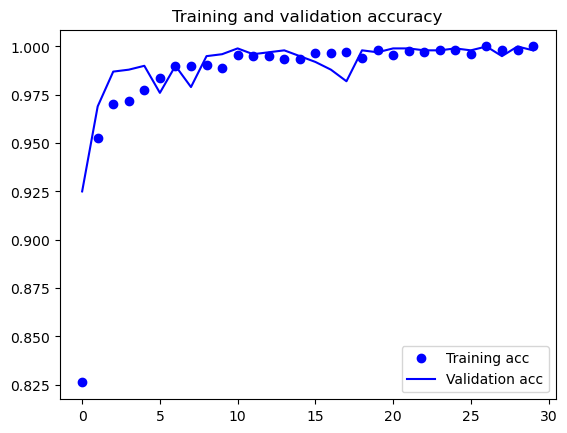

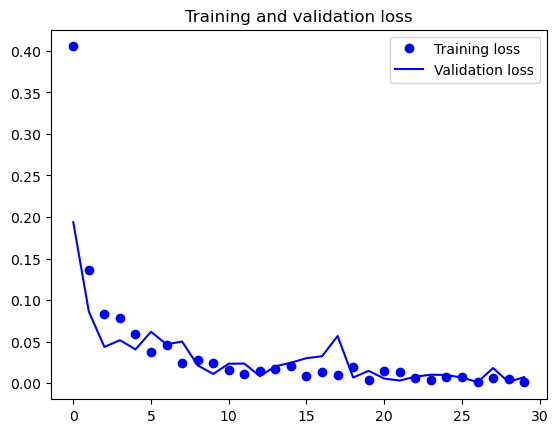

In [11]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

# Load the Model

In [12]:
from keras.preprocessing import image
from keras.models import load_model
model = load_model('kidney_stone_classifier.h5')

# test image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


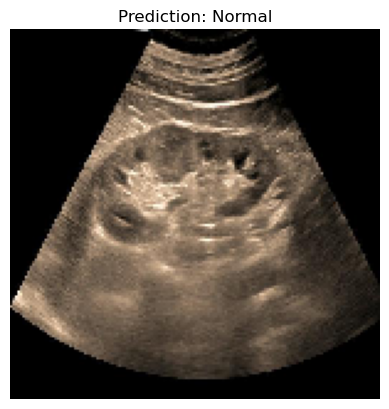

Prediction Score (0 = Normal, 1 = Stone): 0.2291


In [13]:
img_path = 'D:\\Semester-06\\Deep Learning\\Datasets\\KidneyStoneProject\\Normal_7.jpg'

# Load and preprocess the image
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = x / 255.0  

# Make prediction
prediction = model.predict(x)

# Display image with prediction
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {'Stone' if prediction[0][0] >= 0.5 else 'Normal'}")
plt.show()

# Print raw score
print(f"Prediction Score (0 = Normal, 1 = Stone): {prediction[0][0]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


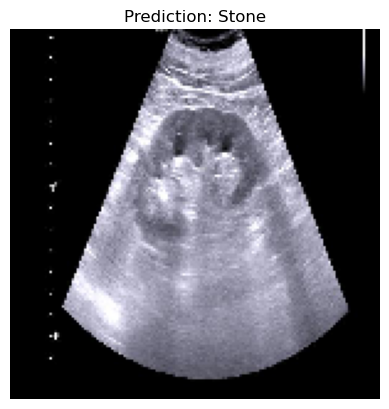

Prediction Score (0 = Normal, 1 = Stone): 1.0000


In [14]:
img_path = 'D:\\Semester-06\\Deep Learning\\Datasets\\KidneyStoneProject\\Stone_5.jpg' 

# Load and preprocess the image
img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = x / 255.0

# Make prediction
prediction = model.predict(x)

# Display image with prediction
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {'Stone' if prediction[0][0] >= 0.5 else 'Normal'}")
plt.show()

# Print raw score
print(f"Prediction Score (0 = Normal, 1 = Stone): {prediction[0][0]:.4f}")